Vazifa : Diabed bor yoki yo'qligini taxmin qilish

In [33]:
#Kutubxonalar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [34]:
#datasetni chaqirib olamiz
df = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/ML/refs/heads/main/diabets.csv')
df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72,35,0,33.6,0.627,50,1
1,1,1,85,66,29,0,26.6,0.351,31,0
2,2,8,183,64,0,0,23.3,0.672,32,1
3,3,1,89,66,23,94,28.1,0.167,21,0
4,4,0,137,40,35,168,43.1,2.288,33,1


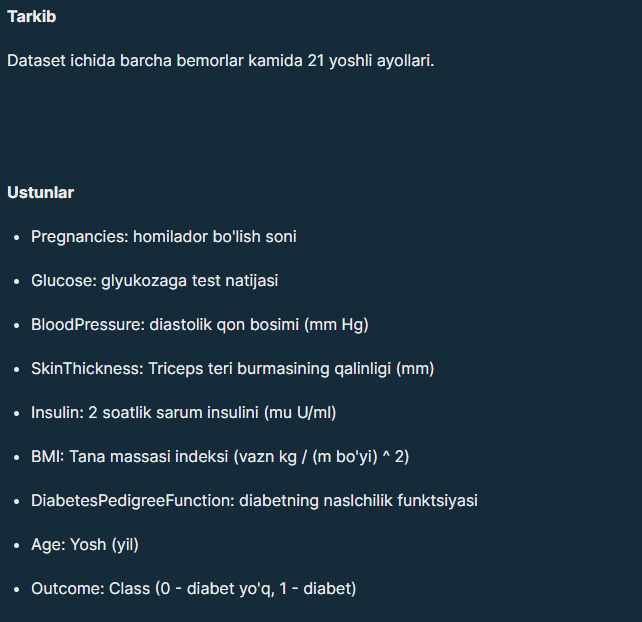

In [35]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [36]:
df.shape

(768, 9)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [38]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [39]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 - diabet yo'q
1 - diabet bor

In [40]:
corelatsiya = df.corr().abs()
corelatsiya.style.background_gradient(cmap='coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,0.081672,0.073535,0.017683,0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,0.113970,0.074752
Insulin,0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,0.113970,0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [41]:
df.corrwith(df['Outcome']).abs().sort_values(ascending=False)

,0
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


ML ga tayyorlaymiz

In [42]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [43]:
#datasetni train va test ga ajratamiz

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)


In [44]:
#Normalizatsiya

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit_transform(x_train)

array([[-0.23855894, -0.77396436, -0.68564477, ..., -0.92309667,
         1.40238924,  0.55652513],
       [-1.13283142, -0.11924844, -0.16241944, ..., -0.14882553,
         0.05770673, -0.94669416],
       [ 0.05953189, -0.33748708,  1.19796641, ...,  0.71429641,
        -0.84272368, -0.23929685],
       ...,
       [ 1.84807685, -0.61807962,  0.88403121, ...,  1.72973398,
         1.97484832,  0.46810046],
       [-1.13283142,  0.62899832, -3.6157066 , ...,  1.32355895,
        -0.80098188, -0.32772151],
       [-1.13283142,  0.13016714,  1.40725654, ..., -1.20234201,
        -0.63103309, -1.03511882]])

In [45]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [46]:
#    ML

from sklearn.neighbors import KNeighborsClassifier

k_nn_model = KNeighborsClassifier(n_neighbors=14)
k_nn_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=14)

In [47]:
y_predict = k_nn_model.predict(x_test)

In [48]:
#  Modelni baholash

from sklearn.metrics import jaccard_score

jaccard_score(y_test, y_predict)

np.float64(0.3783783783783784)

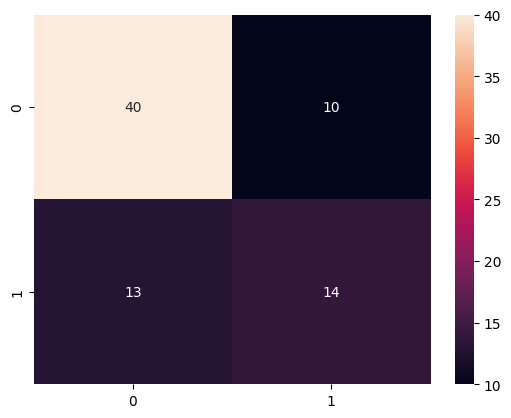

In [49]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 25)}

knn_gscv = GridSearchCV(k_nn_model, param_grid, cv=5)

knn_gscv.fit(x, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=14),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [51]:
knn_gscv.best_params_

{'n_neighbors': np.int64(14)}

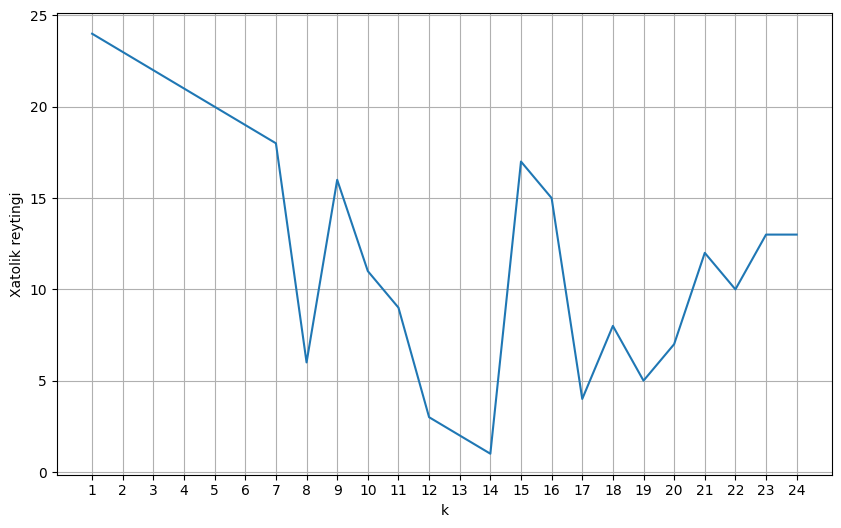

In [52]:
plt.figure(figsize=(10,6))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(param_grid['n_neighbors'])
plt.xlabel("k")
plt.ylabel("Xatolik reytingi")
plt.grid()
plt.show()

In [53]:
#  Eng yaxshi k bilan yangi model yasimiz

k_nn_model_best = KNeighborsClassifier(n_neighbors=14)
k_nn_model_best.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=14)

In [54]:
y_predict = k_nn_model_best.predict(x_test)

In [55]:
jaccard_score(y_test, y_predict)

np.float64(0.3783783783783784)

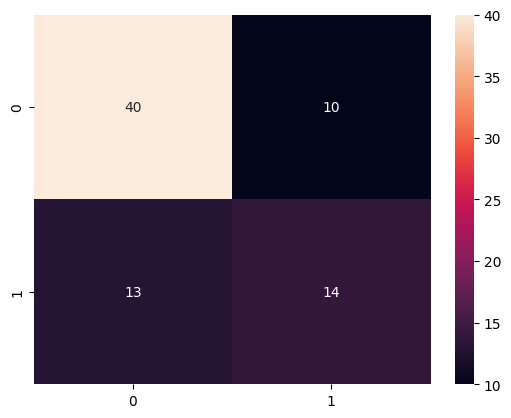

In [56]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

In [57]:
from sklearn.metrics import r2_score

r2_score(y_test, y_predict)

-0.3118518518518518